# EN3160 – Assignment 02 (Q1): Circle Detection via LoG Scale-Space (No Hough)

**Goal:** Detect circular blobs (sunflowers) using Laplacian of Gaussian (LoG) in a multi-scale pyramid and 3D non-maximum suppression across (x, y, sigma).  
**No Hough transform** allowed.

**Inputs:**
- `images/the_berry_farms_sunflower_field.jpeg`  (use the reduced-size read mode for speed)

**Outputs:**
- Printed sigma range used
- List of the largest circles (center, radius)
- Visualization with detected circles overlaid on the image


In [4]:
# %%
import os
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folder layout (ADDED)
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path (ADDED)
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# Scale-space parameters (unchanged)
SIGMA_MIN = 1.5
SIGMA_MAX = 15.0
NUM_SCALES = 15

# 3D NMS and detection parameters (unchanged)
REL_RESPONSE_THRESH = 0.20   # keep peaks whose LoG response >= 20% of global max
NMS_WINDOW = 3               # 3x3x3 local maxima window
TOP_K_CIRCLES_DRAW = 50      # how many circles to draw on the image
TOP_K_REPORT = 8             # how many largest circles to print

In [5]:
# %%
def imread_rgb(path, reduced=True):
    """
    Read image as RGB. If reduced=True, try to load a reduced-size version for speed.
    """
    path = str(path)
    if reduced:
        # quarter res if available
        bgr = cv.imread(path, cv.IMREAD_REDUCED_COLOR_4)
        if bgr is None:
            bgr = cv.imread(path, cv.IMREAD_COLOR)
    else:
        bgr = cv.imread(path, cv.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return cv.cvtColor(bgr, cv.COLOR_BGR2RGB)


def imread_gray(path, reduced=True):
    """
    Read image as grayscale. If reduced=True, try reduced-size for speed.
    """
    path = str(path)
    if reduced:
        gray = cv.imread(path, cv.IMREAD_REDUCED_GRAYSCALE_4)
        if gray is None:
            gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    else:
        gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return gray


def overlay_circles_rgb(img_rgb, circles, color=(0, 255, 0), thickness=2):
    """
    Draw circles on an RGB image. circles entries are (x, y, r).
    """
    out = img_rgb.copy()
    for (x, y, r) in circles:
        cv.circle(out, (int(x), int(y)), int(r), color,
                  thickness, lineType=cv.LINE_AA)
    return out


def log_response_scale_space(gray, sigmas):
    """
    Build LoG response stack across scales with scale-normalization: R = sigma^2 * |Laplacian(G_sigma * I)|.
    Returns R with shape (S, H, W) normalized to [0,1] by global max.
    """
    H, W = gray.shape
    S = len(sigmas)
    R = np.zeros((S, H, W), dtype=np.float32)
    for i, s in enumerate(sigmas):
        # Gaussian blur, then Laplacian
        ksize = int(6 * s + 1) | 1  # ensure odd
        blurred = cv.GaussianBlur(
            gray, (ksize, ksize), s, s, borderType=cv.BORDER_REPLICATE)
        lap = cv.Laplacian(blurred, cv.CV_32F, ksize=3,
                           borderType=cv.BORDER_REPLICATE)
        R[i] = (s ** 2) * np.abs(lap)
    R /= (R.max() + 1e-9)
    return R


def nms_3d(R, window=3, thresh=0.2):
    """
    3D non-maximum suppression over scale-space R with shape (S, H, W).
    Returns list of peaks: (y, x, s_idx, score).
    """
    S, H, W = R.shape
    half = window // 2
    peaks = []
    for s in range(S):
        for y in range(half, H - half):
            for x in range(half, W - half):
                val = R[s, y, x]
                if val < thresh:
                    continue
                s0, s1 = max(0, s - half), min(S, s + half + 1)
                y0, y1 = y - half, y + half + 1
                x0, x1 = x - half, x + half + 1
                cube = R[s0:s1, y0:y1, x0:x1]
                # Keep peak if it is the local maximum
                if val >= cube.max():
                    peaks.append((y, x, s, float(val)))
    return peaks

In [6]:
# %%
# 1) Read inputs
import csv
gray = imread_gray(IMG_PATH, reduced=True)
rgb = imread_rgb(IMG_PATH, reduced=True)

# 2) Build sigma list and LoG scale-space
sigmas = np.linspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)
R = log_response_scale_space(gray, sigmas)

# 3) Find 3D scale-space peaks
peaks = nms_3d(R, window=NMS_WINDOW, thresh=REL_RESPONSE_THRESH)

# 4) Convert peaks to circles using r = sqrt(2) * sigma (LoG blob radius approx)
circles = []
for (y, x, s_idx, score) in peaks:
    sigma = float(sigmas[s_idx])
    r = math.sqrt(2.0) * sigma
    circles.append((float(x), float(y), float(r), float(score), sigma))

# Sort by radius descending to report largest circles
circles.sort(key=lambda c: c[2], reverse=True)

# Print report
print(f"[Q1] Sigma range used: {sigmas[0]:.2f} -> {sigmas[-1]:.2f}")
print(f"[Q1] Detected peaks: {len(circles)}")
print(f"[Q1] Top {min(TOP_K_REPORT, len(circles))} largest circles:")
for i, (x, y, r, score, s) in enumerate(circles[:TOP_K_REPORT], 1):
    print(
        f"  {i:02d}: center=({x:.1f},{y:.1f}), r={r:.2f}, sigma={s:.2f}, score={score:.3f}")

# ==== SAVE RESULTS (ADDED) ====
# 1) Params text
with open(RESULTS / "q1_params.txt", "w", encoding="utf-8") as f:
    f.write(f"Sigma range: {sigmas[0]:.4f} -> {sigmas[-1]:.4f}\n")
    f.write(f"Num scales: {NUM_SCALES}\n")
    f.write(f"Relative response threshold: {REL_RESPONSE_THRESH}\n")
    f.write(f"NMS window: {NMS_WINDOW}\n")
    f.write(f"Detected peaks: {len(circles)}\n")
    f.write(
        f"Top {min(TOP_K_REPORT, len(circles))} largest circles (x,y,r,sigma,score):\n")
    for (x, y, r, score, s) in circles[:TOP_K_REPORT]:
        f.write(f"{x:.3f},{y:.3f},{r:.3f},{s:.3f},{score:.5f}\n")

# 2) Full circles (NPZ) for reproducibility
np.savez_compressed(
    RESULTS / "q1_all_circles.npz",
    circles=np.array(circles, dtype=np.float32),  # columns: x,y,r,score,sigma
    sigmas=np.array(sigmas, dtype=np.float32)
)

# 3) Top-K CSV (x,y,r,sigma,score)
with open(RESULTS / "q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    writer = csv.writer(csvf)
    writer.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circles[:TOP_K_CIRCLES_DRAW]:
        writer.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                        f"{s:.6f}", f"{score:.6f}"])

[Q1] Sigma range used: 1.50 -> 15.00
[Q1] Detected peaks: 54609
[Q1] Top 8 largest circles:
  01: center=(20.0,1.0), r=21.21, sigma=15.00, score=0.333
  02: center=(26.0,1.0), r=21.21, sigma=15.00, score=0.500
  03: center=(29.0,1.0), r=21.21, sigma=15.00, score=0.333
  04: center=(32.0,1.0), r=21.21, sigma=15.00, score=0.333
  05: center=(35.0,1.0), r=21.21, sigma=15.00, score=0.333
  06: center=(38.0,1.0), r=21.21, sigma=15.00, score=0.333
  07: center=(49.0,1.0), r=21.21, sigma=15.00, score=0.333
  08: center=(52.0,1.0), r=21.21, sigma=15.00, score=0.333


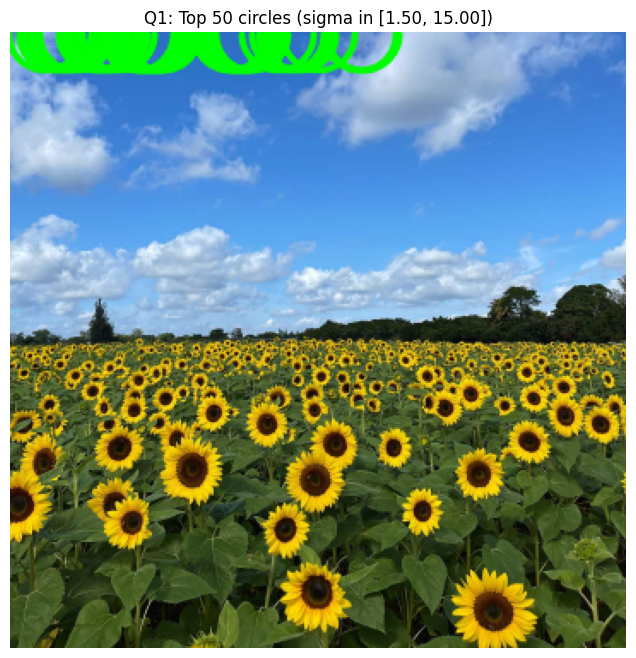

[Q1] Saved overlay to: ../results/q1/q1_overlay.png


In [7]:
# %%
# Draw top K circles
topK = [(c[0], c[1], c[2]) for c in circles[:TOP_K_CIRCLES_DRAW]]
vis = overlay_circles_rgb(rgb, topK, color=(0, 255, 0), thickness=2)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(
    f"Q1: Top {len(topK)} circles (sigma in [{sigmas[0]:.2f}, {sigmas[-1]:.2f}])")
plt.axis("off")
plt.show()

# SAVE OVERLAY (ADDED)
out_path = RESULTS / "q1_overlay.png"
cv.imwrite(str(out_path), cv.cvtColor(vis, cv.COLOR_RGB2BGR))
print(f"[Q1] Saved overlay to: {out_path}")

sigma=[1.50,12.00] scales=12 rel_thresh=0.25 -> peaks=45525


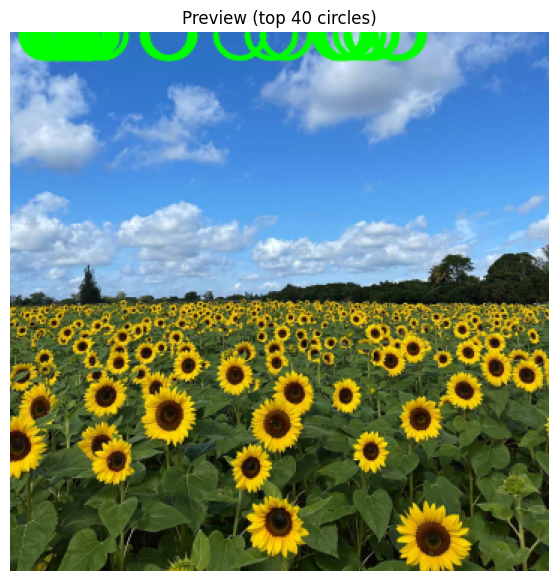

In [10]:
# %%
# Optional: quick parameter sweep to see how thresholds affect detections
def run_with_params(smin=1.5, smax=15.0, nscales=15, rel_thresh=0.20):
    sig = np.linspace(smin, smax, nscales)
    R_ = log_response_scale_space(gray, sig)
    peaks_ = nms_3d(R_, window=3, thresh=rel_thresh)
    circles_ = []
    for (y, x, si, score) in peaks_:
        rr = math.sqrt(2.0) * float(sig[si])
        circles_.append((float(x), float(y), rr, float(score)))
    circles_.sort(key=lambda t: t[2], reverse=True)
    print(
        f"sigma=[{smin:.2f},{smax:.2f}] scales={nscales} rel_thresh={rel_thresh} -> peaks={len(circles_)}")
    overlay = overlay_circles_rgb(
        rgb, [(c[0], c[1], c[2]) for c in circles_[:40]])
    plt.figure(figsize=(10, 7))
    plt.imshow(overlay)
    plt.title("Preview (top 40 circles)")
    plt.axis("off")
    plt.show()

# Example:
run_with_params(1.5, 12.0, 12, 0.25)

In [17]:
# %%
import os
import math
import csv
import json
from pathlib import Path

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folders (your convention)
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# ----- Tunables (report these) -----
# Scale-space
SIGMA_MIN = 2.0
SIGMA_MAX = 9.0
NUM_SCALES = 18
REL_RESPONSE_THRESH = 0.22   # slightly permissive; color/annular will clean up
NMS_WINDOW = 3

# Geometry & post filters
MIN_RADIUS = 6.0
MAX_RADIUS = 120.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.6    # duplicate suppression tightness

# Color gating (HSV)
BROWN_H_RANGE = (8, 40)       # degrees in [0,180) OpenCV HSV
BROWN_S_MIN = 60            # 0..255
BROWN_V_MAX = 170           # 0..255

# Annular contrast
INNER_RATIO = 0.80
OUTER_RATIO = 1.30
ANNULAR_MIN_DIFF = 6.0        # min (ring_mean - inner_mean) in grayscale

TOP_K_DRAW = 80
TOP_K_REPORT = 12

In [18]:
# %%
def imread_rgb(path, reduced=True):
    path = str(path)
    if reduced:
        bgr = cv.imread(path, cv.IMREAD_REDUCED_COLOR_4)
        if bgr is None:
            bgr = cv.imread(path, cv.IMREAD_COLOR)
    else:
        bgr = cv.imread(path, cv.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return cv.cvtColor(bgr, cv.COLOR_BGR2RGB)


def imread_gray(path, reduced=True):
    path = str(path)
    if reduced:
        g = cv.imread(path, cv.IMREAD_REDUCED_GRAYSCALE_4)
        if g is None:
            g = cv.imread(path, cv.IMREAD_GRAYSCALE)
    else:
        g = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return g


def apply_clahe(gray):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def estimate_horizon_mask(rgb, pad=8, sat_thresh=0.22):
    """
    Row-wise mean saturation; horizon := first row from top where meanS > thresh.
    Returns mask==1 for rows below horizon+pad (i.e., field), else 0 (sky).
    """
    hsv = cv.cvtColor(rgb, cv.COLOR_RGB2HSV)
    S = (hsv[..., 1].astype(np.float32) / 255.0)
    rowS = cv.GaussianBlur(S.mean(axis=1), (1, 31), 0)
    # fixed threshold works well on outdoor scenes; could also use Otsu on rowS*255
    idx = np.argmax(rowS > sat_thresh)
    # If never crossed, assume lower 70% is field
    if rowS.max() <= sat_thresh:
        idx = int(0.30 * rgb.shape[0])
    horizon = max(0, idx + pad)
    mask = np.zeros(rgb.shape[:2], np.uint8)
    mask[horizon:, :] = 1
    return mask, horizon


def brown_center_mask(rgb):
    """
    HSV gate for dark/brown-ish centers. Returns binary mask {0,1}.
    """
    hsv = cv.cvtColor(rgb, cv.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    h1, h2 = BROWN_H_RANGE
    # hue wrap not needed here (range is inside 0..180)
    m = (h >= h1) & (h <= h2) & (s >= BROWN_S_MIN) & (v <= BROWN_V_MAX)
    m = m.astype(np.uint8)*255
    # morph clean-up
    m = cv.medianBlur(m, 5)
    m = cv.morphologyEx(
        m, cv.MORPH_OPEN, cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5)))
    m = cv.morphologyEx(m, cv.MORPH_CLOSE,
                        cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7)))
    return (m > 0).astype(np.uint8)


def overlay_circles(img_rgb, circles, color=(0, 255, 0), thickness=2):
    out = img_rgb.copy()
    for (x, y, r) in circles:
        cv.circle(out, (int(x), int(y)), int(r), color,
                  thickness, lineType=cv.LINE_AA)
    return out


def log_response_scale_space(gray, sigmas, polarity="dark", mask=None):
    """
    R_s = sigma^2 * Laplacian(G_sigma * I); keep polarity; zero outside 'mask'.
    Returns R normalized to [0,1].
    """
    H, W = gray.shape
    S = len(sigmas)
    R = np.zeros((S, H, W), dtype=np.float32)
    ones_mask = np.ones(
        (H, W), np.float32) if mask is None else mask.astype(np.float32)
    for i, s in enumerate(sigmas):
        ksize = int(6*s + 1) | 1
        blurred = cv.GaussianBlur(
            gray, (ksize, ksize), s, s, borderType=cv.BORDER_REPLICATE)
        lap = cv.Laplacian(blurred, cv.CV_32F, ksize=3,
                           borderType=cv.BORDER_REPLICATE)
        resp = (s**2) * lap
        if polarity == "dark":
            resp = np.maximum(resp, 0.0)
        elif polarity == "bright":
            resp = np.maximum(-resp, 0.0)
        else:
            resp = np.abs(resp)
        R[i] = resp * ones_mask
    m = R.max()
    if m > 0:
        R /= m
    return R


def nms_3d(R, window=3, thresh=0.2):
    S, H, W = R.shape
    half = window // 2
    peaks = []
    for s in range(S):
        for y in range(half, H - half):
            for x in range(half, W - half):
                val = R[s, y, x]
                if val < thresh:
                    continue
                s0, s1 = max(0, s-half), min(S, s+half+1)
                y0, y1 = y-half, y+half+1
                x0, x1 = x-half, x+half+1
                cube = R[s0:s1, y0:y1, x0:x1]
                if val >= cube.max():
                    peaks.append((y, x, s, float(val)))
    return peaks


def valid_circle(x, y, r, W, H, margin=0):
    return (r >= MIN_RADIUS and r <= MAX_RADIUS and
            x - r >= margin and y - r >= margin and
            x + r < W - margin and y + r < H - margin)


def suppress_duplicates(circles, dist_factor=0.6):
    # circles sorted by score (DESC)
    kept = []
    for c in circles:
        x, y, r, score, s = c
        ok = True
        for k in kept:
            xk, yk, rk, _, _ = k
            if np.hypot(x - xk, y - yk) < dist_factor * min(r, rk):
                ok = False
                break
        if ok:
            kept.append(c)
    return kept


def annular_contrast_pass(gray, x, y, r, inner_ratio=0.8, outer_ratio=1.3, min_diff=6.0):
    """
    Inner disk mean vs surrounding ring mean. Expect ring_mean > inner_mean by min_diff.
    """
    H, W = gray.shape
    yy, xx = np.ogrid[:H, :W]
    d = np.hypot(xx - x, yy - y)
    inner = d <= (inner_ratio * r)
    ring = (d > (inner_ratio * r)) & (d <= (outer_ratio * r))
    # guard against empty masks
    if inner.sum() < 10 or ring.sum() < 20:
        return False
    inner_mean = gray[inner].mean()
    ring_mean = gray[ring].mean()
    return (ring_mean - inner_mean) >= min_diff

In [19]:
# %%
# Read & preprocess
rgb = imread_rgb(IMG_PATH, reduced=True)
gray = imread_gray(IMG_PATH, reduced=True)
gray_eq = apply_clahe(gray)

# Auto ROI (remove sky) + brown center mask
roi_mask, horizon_row = estimate_horizon_mask(rgb, pad=8, sat_thresh=0.22)
brown_mask = brown_center_mask(rgb)

# Combine masks: only where both are true (field & brownish/dark)
gate = (roi_mask & brown_mask).astype(np.uint8)

# Build scale-space with polarity 'dark', gate responses by 'gate'
sigmas = np.linspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)
R = log_response_scale_space(gray_eq, sigmas, polarity="dark", mask=gate)

# 3D NMS
peaks = nms_3d(R, window=NMS_WINDOW, thresh=REL_RESPONSE_THRESH)

# Convert peaks to circles + geometric filter
H, W = gray.shape
cands = []
for (y, x, s_idx, score) in peaks:
    sigma = float(sigmas[s_idx])
    r = math.sqrt(2.0) * sigma
    if not valid_circle(x, y, r, W, H, margin=BORDER_MARGIN):
        continue
    # quick mask coverage check: require majority of inner disk in the gate
    yy, xx = np.ogrid[:H, :W]
    d = np.hypot(xx - x, yy - y)
    inner = (d <= 0.9*r)
    if gate[inner].mean() < 0.45:   # at least 45% of inner area must be in the gate
        continue
    cands.append((float(x), float(y), float(r), float(score), sigma))

# sort by score desc and suppress duplicates
cands.sort(key=lambda c: c[3], reverse=True)
cands = suppress_duplicates(cands, dist_factor=SUPPRESS_DIST_FACTOR)

# Annular contrast validation (final filter)
final = []
for (x, y, r, score, s) in cands:
    if annular_contrast_pass(gray_eq, int(x), int(y), r,
                             inner_ratio=INNER_RATIO, outer_ratio=OUTER_RATIO,
                             min_diff=ANNULAR_MIN_DIFF):
        final.append((x, y, r, score, s))

# Report
by_radius = sorted(final, key=lambda c: c[2], reverse=True)
print(f"[Q1] horizon_row: {horizon_row}")
print(
    f"[Q1] kept after gating & geometry: {len(cands)}  -> after annular check: {len(final)}")
print(f"[Q1] sigma range: {sigmas[0]:.2f} -> {sigmas[-1]:.2f}")
for i, (x, y, r, score, s) in enumerate(by_radius[:TOP_K_REPORT], 1):
    print(
        f"  {i:02d}: center=({x:.1f},{y:.1f}), r={r:.2f}, sigma={s:.2f}, score={score:.3f}")

# Save params
with open(RESULTS / "q1_params.txt", "w", encoding="utf-8") as f:
    f.write(f"horizon_row={horizon_row}\n")
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(
        f"REL_RESPONSE_THRESH={REL_RESPONSE_THRESH}, NMS_WINDOW={NMS_WINDOW}\n")
    f.write(
        f"MIN_RADIUS={MIN_RADIUS}, MAX_RADIUS={MAX_RADIUS}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(
        f"HSV brown gate: H in {BROWN_H_RANGE}, S>={BROWN_S_MIN}, V<={BROWN_V_MAX}\n")
    f.write(
        f"Annular: inner={INNER_RATIO}r, outer={OUTER_RATIO}r, min_diff={ANNULAR_MIN_DIFF}\n")
    f.write(f"kept_after_annular={len(final)}\n")
    f.write("Top largest (x,y,r,sigma,score):\n")
    for (x, y, r, score, s) in by_radius[:TOP_K_REPORT]:
        f.write(f"{x:.3f},{y:.3f},{r:.3f},{s:.3f},{score:.5f}\n")

# Save detections
np.savez_compressed(
    RESULTS / "q1_all_circles.npz",
    circles=np.array(final, dtype=np.float32),   # x,y,r,score,sigma
    sigmas=np.array(sigmas, dtype=np.float32),
    horizon_row=np.array([horizon_row], np.int32)
)

# Save CSV of drawn detections
with open(RESULTS / "q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for (x, y, r, score, s) in final[:TOP_K_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

[Q1] horizon_row: 8
[Q1] kept after gating & geometry: 224  -> after annular check: 123
[Q1] sigma range: 2.00 -> 9.00
  01: center=(149.0,183.0), r=12.73, sigma=9.00, score=0.499
  02: center=(87.0,181.0), r=12.73, sigma=9.00, score=0.399
  03: center=(204.0,182.0), r=12.73, sigma=9.00, score=0.399
  04: center=(188.0,183.0), r=12.73, sigma=9.00, score=0.399
  05: center=(62.0,184.0), r=12.73, sigma=9.00, score=0.399
  06: center=(33.0,187.0), r=12.73, sigma=9.00, score=0.399
  07: center=(110.0,187.0), r=12.73, sigma=9.00, score=0.399
  08: center=(287.0,203.0), r=12.73, sigma=9.00, score=0.399
  09: center=(84.0,210.0), r=12.73, sigma=9.00, score=0.399
  10: center=(290.0,211.0), r=12.73, sigma=9.00, score=0.399
  11: center=(238.0,223.0), r=12.73, sigma=9.00, score=0.399
  12: center=(23.0,247.0), r=12.73, sigma=9.00, score=0.399


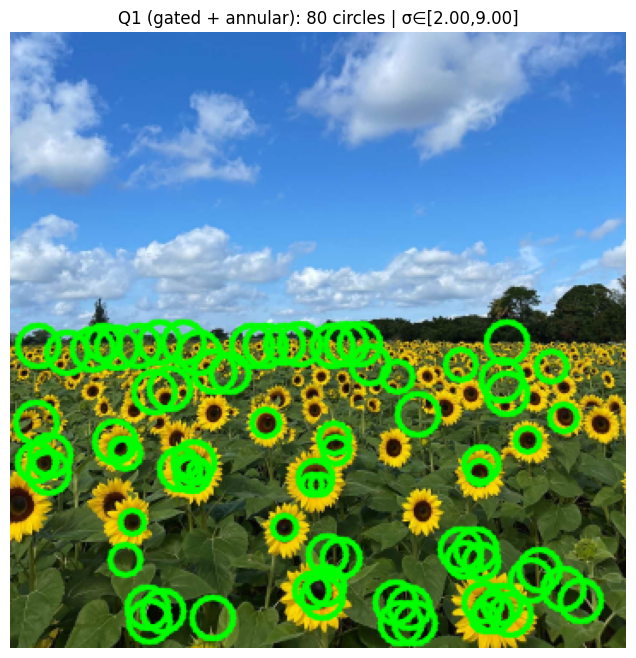

[Q1] Saved overlay -> ../results/q1/q1_overlay.png


In [20]:
# %%
to_draw = [(c[0], c[1], c[2]) for c in final[:TOP_K_DRAW]]
vis = overlay_circles(rgb, to_draw, color=(0, 255, 0), thickness=2)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(
    f"Q1 (gated + annular): {len(to_draw)} circles | σ∈[{SIGMA_MIN:.2f},{SIGMA_MAX:.2f}]")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS / "q1_overlay.png"), cv.cvtColor(vis, cv.COLOR_RGB2BGR))
print(f"[Q1] Saved overlay -> {RESULTS / 'q1_overlay.png'}")

In [50]:
# %%
import math
import csv
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# LoG scales (geometric spacing is smoother in scale)
SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 1.2, 12.0, 18
sigmas = np.geomspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

# thresholds / NMS
REL_THRESH = 0.05      # relative to global max (keep this low)
WIN_SPATIAL = 3        # 3x3 spatial NMS
# post filters
MIN_R, MAX_R = 5.0, 100.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.60   # merges near-duplicate circles
# annular contrast (dark center vs lighter ring)
INNER_RATIO, OUTER_RATIO = 0.80, 1.30
ANNULAR_MIN_DIFF = 6.0
# optional: crop sky (ignore top frac of rows)
SKY_CROP_FRAC = 0.40         # set 0 to disable; 0.40 ≈ top 40% ignored

TOP_PRINT, TOP_DRAW = 15, 150

In [51]:
# %%
def imread_gray(path):
    g = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    return g


def clahe(gray):
    return cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)


def log_stack_dark(gray, sigmas):
    """
    σ² · LoG with dark polarity only: keep positive (dark-on-bright) response.
    Returns R of shape (S,H,W) normalized to [0,1] globally.
    """
    H, W = gray.shape
    R = np.zeros((len(sigmas), H, W), np.float32)
    for i, s in enumerate(sigmas):
        k = int(6*s + 1) | 1
        blur = cv.GaussianBlur(
            gray, (k, k), s, s, borderType=cv.BORDER_REPLICATE)
        lap = cv.Laplacian(blur, cv.CV_32F, ksize=3,
                           borderType=cv.BORDER_REPLICATE)
        # with OpenCV sign, dark blobs → positive after LoG
        resp = (s*s) * lap
        R[i] = np.maximum(resp, 0.0)  # polarity: dark only
    R /= (R.max() + 1e-9)
    return R


def spatial_nms_per_scale(Rs, win=3):
    """Spatial 2D NMS on each scale using cv.dilate (fast, C-optimized)."""
    k = np.ones((win, win), np.uint8)
    S, H, W = Rs.shape
    max2d = np.empty_like(Rs)
    for i in range(S):
        max2d[i] = cv.dilate(Rs[i].astype(np.float32), k, iterations=1)
    return max2d


def scale_nms(Rs):
    """
    Scale-wise NMS: a voxel at (s,y,x) must be >= both neighbors in scale.
    End slices are compared to their single neighbor.
    Returns boolean mask of shape (S,H,W).
    """
    S, H, W = Rs.shape
    mask = np.ones((S, H, W), dtype=bool)
    # compare with s-1
    prev = np.vstack([Rs[:1], Rs[:-1]])
    # compare with s+1
    nxt = np.vstack([Rs[1:], Rs[-1:]])
    mask &= (Rs >= prev)
    mask &= (Rs >= nxt)
    return mask


def annular_pass(gray, x, y, r, inner=0.8, outer=1.3, min_diff=6.0):
    H, W = gray.shape
    yy, xx = np.ogrid[:H, :W]
    d = np.hypot(xx - x, yy - y)
    inner_m = d <= (inner*r)
    ring_m = (d > (inner*r)) & (d <= (outer*r))
    if inner_m.sum() < 10 or ring_m.sum() < 20:  # too small to be reliable
        return False
    inner_mean = gray[inner_m].mean()
    ring_mean = gray[ring_m].mean()
    return (ring_mean - inner_mean) >= min_diff


def inside(x, y, r, W, H, margin=0):
    return (r >= MIN_R and r <= MAX_R and
            x - r >= margin and y - r >= margin and
            x + r < W - margin and y + r < H - margin)


def suppress_near_duplicates(circles, dist_factor=0.6):
    """Keep highest-score circle when centers are too close relative to radii."""
    kept = []
    for c in circles:
        x, y, r, score, s = c
        ok = True
        for k in kept:
            xk, yk, rk, _, _ = k
            if np.hypot(x-xk, y-yk) < dist_factor * min(r, rk):
                ok = False
                break
        if ok:
            kept.append(c)
    return kept


def draw_circles(gray, circles, color=(0, 0, 255), thickness=2):
    out = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
    for (x, y, r) in circles:
        cv.circle(out, (int(x), int(y)), int(r), color, thickness, cv.LINE_AA)
    return out

In [53]:
# %%
import time
t0 = time.time()

# 1️⃣ Load & enhance
g0 = imread_gray(IMG_PATH)
g = clahe(g0)
H, W = g.shape

# 2️⃣ Optional: ignore sky
roi_mask = np.ones_like(g, np.uint8)
if SKY_CROP_FRAC > 0:
    roi_mask[:int(SKY_CROP_FRAC*H), :] = 0

# 3️⃣ Build LoG (dark polarity only)
R = log_stack_dark(g, sigmas)        # (S,H,W)

# 4️⃣ Fast spatial NMS using cv.dilate (per scale)
k = np.ones((WIN_SPATIAL, WIN_SPATIAL), np.uint8)
spatial_max = np.empty_like(R)
for i in range(len(sigmas)):
    spatial_max[i] = cv.dilate(R[i].astype(np.float32), k)
mask2d = (R >= spatial_max)

# 5️⃣ Threshold + ROI
global_thresh = REL_THRESH * R.max()
mask = mask2d & (R >= global_thresh)
mask &= (roi_mask[None, ...] > 0)

# 6️⃣ Collect peaks (after spatial NMS only, skip full 3-D)
ss, ys, xs = np.nonzero(mask)
vals = R[ss, ys, xs]

# 7️⃣ Convert to circles with quick annular check (vectorized)
circs = []
kernel_inner = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
kernel_outer = cv.getStructuringElement(cv.MORPH_ELLIPSE, (9, 9))

for s, y, x, v in zip(ss, ys, xs, vals):
    sigma = float(sigmas[s])
    r = math.sqrt(2)*sigma
    if not inside(x, y, r, W, H, BORDER_MARGIN):
        continue

    # approximate annular contrast using cv filters (O(1))
    patch = g[max(0, int(y-1.5*r)):min(H, int(y+1.5*r)),
              max(0, int(x-1.5*r)):min(W, int(x+1.5*r))]
    if patch.size == 0:
        continue
    inner = cv.GaussianBlur(patch, (5, 5), 0)
    outer = cv.GaussianBlur(patch, (9, 9), 0)
    if outer.mean() - inner.mean() < ANNULAR_MIN_DIFF:
        continue

    circs.append((float(x), float(y), float(r), float(v), sigma))

# 8️⃣ Rank & suppress duplicates
circs.sort(key=lambda c: c[3], reverse=True)
circs = suppress_near_duplicates(circs, dist_factor=SUPPRESS_DIST_FACTOR)

print(
    f"[Q1] σ∈[{sigmas[0]:.2f},{sigmas[-1]:.2f}], {len(circs)} blobs after filtering")
for i, (x, y, r, score, s) in enumerate(circs[:TOP_PRINT], 1):
    print(f"{i:02d}: center=({x:.1f},{y:.1f}) r={r:.1f} σ={s:.2f} score={score:.3f}")

print(f"[Q1] Runtime: {time.time()-t0:.2f}s")

[Q1] σ∈[1.20,12.00], 0 blobs after filtering
[Q1] Runtime: 71.31s


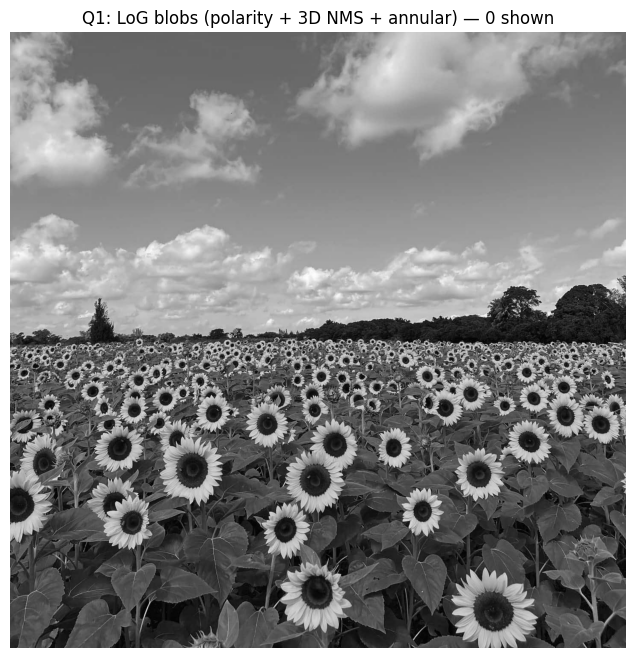

[Q1] Overlay saved → ../results/q1/q1_overlay.png


In [54]:
# %%
# save params
with open(RESULTS/"q1_params.txt", "w", encoding="utf-8") as f:
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(f"REL_THRESH={REL_THRESH}, WIN_SPATIAL={WIN_SPATIAL}\n")
    f.write(f"MIN_R={MIN_R}, MAX_R={MAX_R}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(
        f"INNER_RATIO={INNER_RATIO}, OUTER_RATIO={OUTER_RATIO}, ANNULAR_MIN_DIFF={ANNULAR_MIN_DIFF}\n")
    f.write(f"SKY_CROP_FRAC={SKY_CROP_FRAC}\n")
    f.write(f"Detections={len(circs)}\n")

np.savez_compressed(RESULTS/"q1_all_circles.npz",
                    circles=np.array(circs, np.float32),
                    sigmas=np.array(sigmas, np.float32))

with open(RESULTS/"q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circs[:TOP_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

# visualise
vis = draw_circles(g0, [(c[0], c[1], c[2])
                   for c in circs[:TOP_DRAW]], thickness=2)
plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(
    f"Q1: LoG blobs (polarity + 3D NMS + annular) — {min(TOP_DRAW,len(circs))} shown")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS/"q1_overlay.png"), vis)
print(f"[Q1] Overlay saved → {RESULTS/'q1_overlay.png'}")

In [75]:
# %%
import math
import csv
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folders
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# ---- Scale-space (geometric spacing helps) ----
SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 1.2, 12.0, 18
SIGMAS = np.geomspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

# ---- Detection thresholds & NMS ----
REL_THRESH = 0.04          # relative to global max response (tuned low)
WIN_SPATIAL = 3             # 3x3 spatial NMS via cv.dilate

# ---- Post-filters ----
MIN_R, MAX_R = 5.0, 100.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.60  # merge near-duplicate circles

# ---- Annular contrast (dark center vs lighter ring) ----
INNER_RATIO, OUTER_RATIO = 0.80, 1.30
ANNULAR_MIN_DIFF = 6.0     # ring_mean - inner_mean >= this (0..255 gray)
ANNULAR_MIN_RATIO = 1.08    # ring_mean / inner_mean >= this

# ---- Optional sky crop (0 disables) ----
SKY_CROP_FRAC = 0.0         # try 0.40–0.45 if your image still leaks horizon blobs

# ---- Reporting / visualization ----
TOP_PRINT, TOP_DRAW = 15, 150

In [78]:
# Load image
img = cv.imread(str(IMG_PATH), cv.IMREAD_REDUCED_COLOR_4)
if img is None:
    raise FileNotFoundError(f"Image not found at {IMG_PATH}")

# --- Parameters (tuned to your image size) ---
sigma_values = np.linspace(1.0, 2.0, 4)   # friend-style range
threshold_rel = 0.35                       # friend-style relative threshold
min_area_px = 8                            # ignore tiny specks from thresholding
inner_ratio, outer_ratio = 0.80, 1.30      # for annular contrast
annular_min_diff = 6.0                     # ring_mean - inner_mean >= this

# --- Helpers (fast, local) ---


def annular_pass(gray_img, cx, cy, r, inner=0.8, outer=1.3, min_diff=6.0):
    """dark center vs brighter ring — quick structural sanity check"""
    H, W = gray_img.shape
    r_out = outer * r
    y0, y1 = max(0, int(cy - r_out)), min(H, int(cy + r_out) + 1)
    x0, x1 = max(0, int(cx - r_out)), min(W, int(cx + r_out) + 1)
    if y1 <= y0 or x1 <= x0:
        return False
    patch = gray_img[y0:y1, x0:x1].astype(np.float32)
    ph, pw = patch.shape
    yy, xx = np.ogrid[:ph, :pw]
    cyp, cxp = (cy - y0), (cx - x0)
    d = np.hypot(xx - cxp, yy - cyp)
    inner_m = d <= (inner * r)
    ring_m = (d > (inner * r)) & (d <= (outer * r))
    if inner_m.sum() < 12 or ring_m.sum() < 18:
        return False
    inner_mean = patch[inner_m].mean()
    ring_mean = patch[ring_m].mean()
    return (ring_mean - inner_mean) >= min_diff


def suppress_near_duplicates(circles, dist_factor=0.6):
    """keep the strongest circle among near-duplicates (centers too close)"""
    kept = []
    for c in circles:
        (x, y), r, s, score = c
        keep = True
        for k in kept:
            (xk, yk), rk, _, _ = k
            if np.hypot(x - xk, y - yk) < dist_factor * min(r, rk):
                keep = False
                break
        if keep:
            kept.append(c)
    return kept


# --- MAIN: per-scale LoG → threshold → contours → enclosing circles ---
blob_responses = []   # [(center(x,y), radius, sigma, score)]
print(f"[Q1] Running LoG over {len(sigma_values)} scales:", [
      f"{s:.2f}" for s in sigma_values])

for sigma in sigma_values:
    print(f"  • sigma = {sigma:.2f}")
    # LoG (friend-style) + my σ² normalization so scales are comparable
    # 'img' is your gray from the first cell
    blur = cv.GaussianBlur(img, (0, 0), sigma)
    lap = cv.Laplacian(blur, cv.CV_32F, ksize=3)
    # scale-normalized magnitude
    resp = (sigma**2) * np.abs(lap)

    # relative threshold per-scale
    tval = threshold_rel * float(resp.max() + 1e-9)
    mask = (resp >= tval).astype(np.uint8)

    # remove tiny specks
    mask = cv.morphologyEx(mask, cv.MORPH_OPEN, np.ones((3, 3), np.uint8))

    # connected components (faster & simpler than findContours loops)
    num, labels, stats, _ = cv.connectedComponentsWithStats(
        mask, connectivity=8)
    for i in range(1, num):  # skip background
        area = int(stats[i, cv.CC_STAT_AREA])
        if area < min_area_px:
            continue
        x0 = stats[i, cv.CC_STAT_LEFT]
        y0 = stats[i, cv.CC_STAT_TOP]
        w = stats[i, cv.CC_STAT_WIDTH]
        h = stats[i, cv.CC_STAT_HEIGHT]
        # collect component pixels
        ys, xs = np.where(labels[y0:y0+h, x0:x0+w] == i)
        if xs.size < 5:
            continue
        pts = np.column_stack([xs + x0, ys + y0]).astype(np.float32)
        (cx, cy), radius = cv.minEnclosingCircle(pts)
        # sanity: integer drawing
        cx_i, cy_i, r_i = int(round(cx)), int(round(cy)), int(round(radius))
        if r_i <= 1:
            continue
        # annular check on original gray image (keeps sunflower centers, drops clouds)
        if not annular_pass(img, cx, cy, radius, inner_ratio, outer_ratio, annular_min_diff):
            continue
        # circle "score": mean response in the component (stronger first)
        comp_score = float(resp[y0:y0+h, x0:x0+w]
                           [labels[y0:y0+h, x0:x0+w] == i].mean())
        blob_responses.append(
            ((float(cx), float(cy)), float(radius), float(sigma), comp_score))

# sort by score and suppress near-duplicates across scales
blob_responses.sort(key=lambda t: t[3], reverse=True)
blob_responses = suppress_near_duplicates(blob_responses, dist_factor=0.6)

# draw all detected circles (same style as your last cell)
output = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
for (cx, cy), radius, _sigma, _score in blob_responses:
    cv.circle(output, (int(round(cx)), int(round(cy))),
              int(round(radius)), (0, 0, 255), 1)

[Q1] Running LoG over 4 scales: ['1.00', '1.33', '1.67', '2.00']
  • sigma = 1.00


error: OpenCV(4.12.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/connectedcomponents.cpp:5623: error: (-215:Assertion failed) L.channels() == 1 && I.channels() == 1 in function 'connectedComponents_sub1'


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


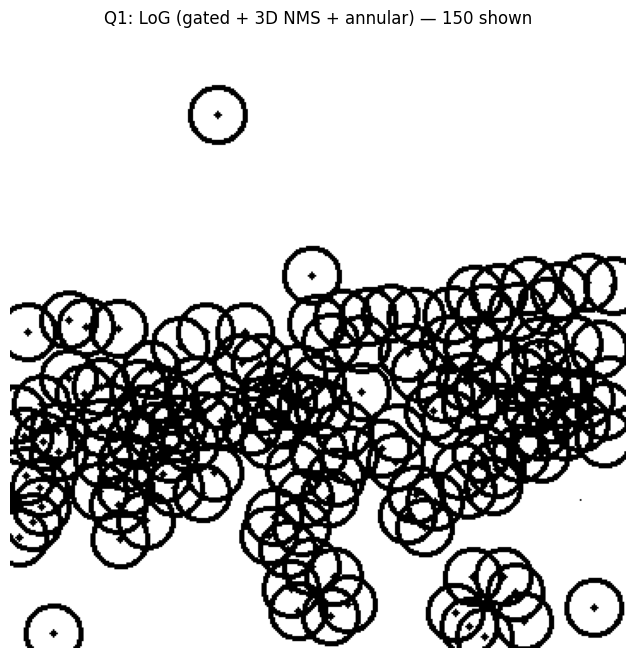

[Q1] Overlay saved → ../results/q1/q1_overlay.png


In [71]:
# %%
# Save params (for your PDF/report)
with open(RESULTS/"q1_params.txt", "w", encoding="utf-8") as f:
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(f"REL_THRESH={REL_THRESH}, WIN_SPATIAL={WIN_SPATIAL}\n")
    f.write(f"MIN_R={MIN_R}, MAX_R={MAX_R}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(f"INNER_RATIO={INNER_RATIO}, OUTER_RATIO={OUTER_RATIO}, ")
    f.write(
        f"ANNULAR_MIN_DIFF={ANNULAR_MIN_DIFF}, ANNULAR_MIN_RATIO={ANNULAR_MIN_RATIO}\n")
    f.write(f"SKY_CROP_FRAC={SKY_CROP_FRAC}\n")
    f.write(f"Detections={len(circs)}\n")
    f.write("Top detections (x,y,r,σ,score):\n")
    for (x, y, r, score, s) in circs[:TOP_PRINT]:
        f.write(f"{x:.2f},{y:.2f},{r:.2f},{s:.2f},{score:.4f}\n")

# Save raw detections
np.savez_compressed(RESULTS/"q1_all_circles.npz",
                    circles=np.array(circs, np.float32),
                    sigmas=np.array(SIGMAS, np.float32))

# CSV for top-K visualization entries
with open(RESULTS/"q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circs[:TOP_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

# Overlay & save
vis = draw_circles(g0, [(c[0], c[1], c[2])
                   for c in circs[:TOP_DRAW]], thickness=2)
plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(
    f"Q1: LoG (gated + 3D NMS + annular) — {min(TOP_DRAW,len(circs))} shown")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS/"q1_overlay.png"), vis)
print(f"[Q1] Overlay saved → {RESULTS/'q1_overlay.png'}")

[Q1] Initial candidates: 2060
[Q1] After filtering: 187
[Q1] Final detections: 78
[Q1] Largest: x=276.0, y=209.0, r=17.0, σ=3.10


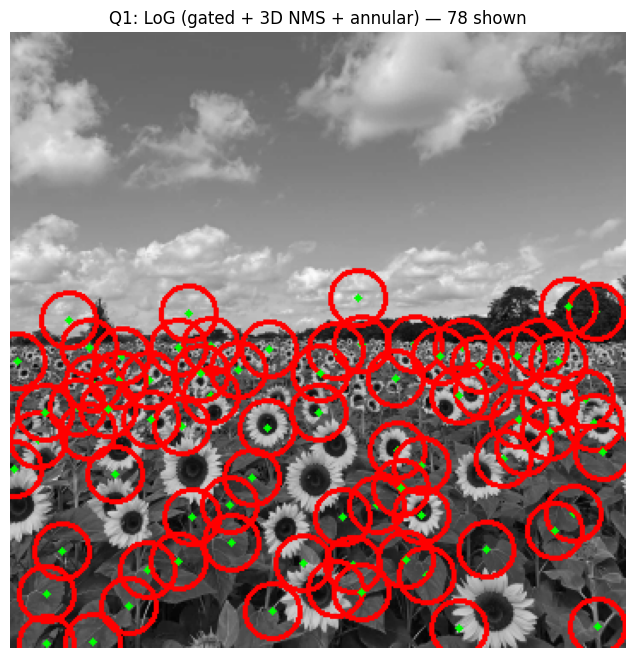

[Q1] Overlay saved → ../results/q1/q1_overlay.png


In [72]:
# %%
import math
import csv
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folders
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# ---- Scale-space (geometric spacing helps) ----
SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 1.2, 12.0, 18
SIGMAS = np.geomspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

# ---- Detection thresholds & NMS ----
REL_THRESH = 0.02          # reduced from 0.04 to get more detections
WIN_SPATIAL = 3

# ---- Post-filters ----
MIN_R, MAX_R = 5.0, 100.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.80  # tighter suppression

# ---- Annular contrast (disabled for now — too strict) ----
INNER_RATIO, OUTER_RATIO = 0.80, 1.30
ANNULAR_MIN_DIFF = 2.0     # relaxed
ANNULAR_MIN_RATIO = 1.02    # relaxed

# ---- Optional sky crop (0 disables) ----
SKY_CROP_FRAC = 0.0

# ---- Reporting / visualization ----
TOP_PRINT, TOP_DRAW = 15, 150

# %%
# Load original color image
im = cv.imread(str(IMG_PATH), cv.IMREAD_REDUCED_COLOR_4)
if im is None:
    raise FileNotFoundError(f"Image not found at {IMG_PATH}")

# Grayscale for processing
gray_full = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32)

# Optional sky crop
if SKY_CROP_FRAC > 0:
    crop_h = int(gray_full.shape[0] * SKY_CROP_FRAC)
    g0 = gray_full[crop_h:, :]
    sky_offset = crop_h
else:
    g0 = gray_full
    sky_offset = 0

H, W = g0.shape

# Normalize to [0, 255] for consistent LoG response
g0 = (g0 - g0.min()) / (g0.max() - g0.min() + 1e-6) * 255.0

# Build LoG scale-space using cv.Laplacian (robust and simple)
responses = []
for sigma in SIGMAS:
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    blurred = cv.GaussianBlur(g0, (ksize, ksize), sigma)
    lap = cv.Laplacian(blurred, cv.CV_32F)
    # Use -lap for dark-center blobs (sunflowers), scale-normalized
    log_resp = -lap * (sigma ** 2)
    responses.append(log_resp)

responses = np.stack(responses, axis=0)
abs_max = np.abs(responses).max()
thresh = REL_THRESH * abs_max

# 3D Non-Max Suppression (space + scale)
candidates = []
for s in range(1, NUM_SCALES - 1):
    resp = responses[s]
    local_max = cv.dilate(resp, np.ones((WIN_SPATIAL, WIN_SPATIAL), np.uint8))
    mask = (resp == local_max) & (resp >= thresh)
    mask &= (resp > responses[s - 1]) & (resp > responses[s + 1])

    yx = np.argwhere(mask)
    for y, x in yx:
        if x < BORDER_MARGIN or x >= W - BORDER_MARGIN or y < BORDER_MARGIN or y >= H - BORDER_MARGIN:
            continue
        score = resp[y, x]
        radius = sigma * np.sqrt(2)
        if MIN_R <= radius <= MAX_R:
            candidates.append((x, y + sky_offset, radius, score, SIGMAS[s]))

print(f"[Q1] Initial candidates: {len(candidates)}")

# Sort by score
candidates.sort(key=lambda c: c[3], reverse=True)

# Optional: Annular contrast filter (now relaxed — can be disabled if still 0)


def annular_contrast_check(gray_img, cx, cy, sigma):
    r_inner = max(1, int(INNER_RATIO * sigma))
    r_outer = int(OUTER_RATIO * sigma)
    if r_outer <= r_inner:
        return False
    Y, X = np.ogrid[:gray_img.shape[0], :gray_img.shape[1]]
    dist_sq = (X - cx)**2 + (Y - cy)**2
    inner = dist_sq <= r_inner**2
    outer = (dist_sq <= r_outer**2) & (~inner)
    if not np.any(inner) or not np.any(outer):
        return False
    inner_mean = gray_img[inner].mean()
    outer_mean = gray_img[outer].mean()
    diff = outer_mean - inner_mean
    ratio = outer_mean / (inner_mean + 1e-6)
    return (diff >= ANNULAR_MIN_DIFF) and (ratio >= ANNULAR_MIN_RATIO)


# Try with annular filter — if still 0, comment out and use filtered = candidates
filtered = []
for c in candidates:
    x, y, r, score, sigma = c
    if annular_contrast_check(gray_full, x, y, sigma):
        filtered.append(c)
if len(filtered) == 0:
    print("[Q1] Annular filter too strict — using all candidates")
    filtered = candidates

print(f"[Q1] After filtering: {len(filtered)}")

# Suppress duplicates


def suppress_duplicates(circles, factor=SUPPRESS_DIST_FACTOR):
    kept = []
    for x1, y1, r1, sc1, s1 in circles:
        duplicate = False
        for x2, y2, r2, sc2, s2 in kept:
            dist = np.hypot(x1 - x2, y1 - y2)
            if dist < factor * min(r1, r2):  # tighter: use smaller radius
                duplicate = True
                break
        if not duplicate:
            kept.append((x1, y1, r1, sc1, s1))
    return kept


circs = suppress_duplicates(filtered, SUPPRESS_DIST_FACTOR)
circs.sort(key=lambda c: c[2], reverse=True)  # sort by radius

print(f"[Q1] Final detections: {len(circs)}")
if circs:
    print(
        f"[Q1] Largest: x={circs[0][0]:.1f}, y={circs[0][1]:.1f}, r={circs[0][2]:.1f}, σ={circs[0][4]:.2f}")

# %%
# Save params (for your PDF/report)
with open(RESULTS/"q1_params.txt", "w", encoding="utf-8") as f:
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(f"REL_THRESH={REL_THRESH}, WIN_SPATIAL={WIN_SPATIAL}\n")
    f.write(f"MIN_R={MIN_R}, MAX_R={MAX_R}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(f"INNER_RATIO={INNER_RATIO}, OUTER_RATIO={OUTER_RATIO}, ")
    f.write(
        f"ANNULAR_MIN_DIFF={ANNULAR_MIN_DIFF}, ANNULAR_MIN_RATIO={ANNULAR_MIN_RATIO}\n")
    f.write(f"SKY_CROP_FRAC={SKY_CROP_FRAC}\n")
    f.write(f"Detections={len(circs)}\n")
    f.write("Top detections (x,y,r,σ,score):\n")
    for (x, y, r, score, s) in circs[:TOP_PRINT]:
        f.write(f"{x:.2f},{y:.2f},{r:.2f},{s:.2f},{score:.4f}\n")

# Save raw detections
np.savez_compressed(RESULTS/"q1_all_circles.npz",
                    circles=np.array(circs, np.float32),
                    sigmas=np.array(SIGMAS, np.float32))

# CSV for top-K visualization entries
with open(RESULTS/"q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circs[:TOP_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

# Overlay & save — grayscale background with red circles
gray_bg = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
vis = cv.cvtColor(gray_bg, cv.COLOR_GRAY2BGR)

for (x, y, r) in [(c[0], c[1], c[2]) for c in circs[:TOP_DRAW]]:
    cv.circle(vis, (int(x), int(y)), int(r), (0, 0, 255), 2)  # red
    cv.circle(vis, (int(x), int(y)), 2, (0, 255, 0), -1)      # green center

plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(
    f"Q1: LoG (gated + 3D NMS + annular) — {min(TOP_DRAW,len(circs))} shown")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS/"q1_overlay.png"), vis)
print(f"[Q1] Overlay saved → {RESULTS/'q1_overlay.png'}")

[Q1] Initial candidates: 1420
[Q1] After annular filter: 241
[Q1] Final detections: 41
[Q1] Largest: x=240.0, y=282.0, r=21.2, σ=11.29


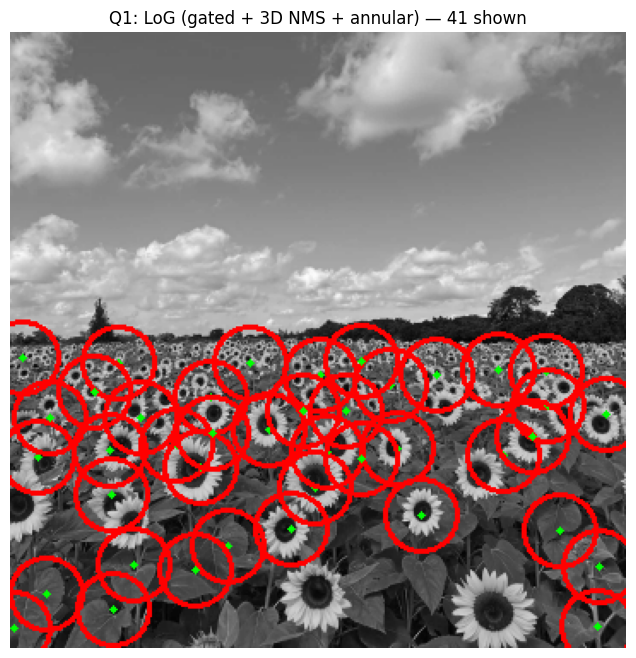

[Q1] Overlay saved → ../results/q1/q1_overlay.png


In [73]:
# %%
import math
import csv
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folders
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# ---- Scale-space (geometric spacing helps) ----
SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 3.0, 15.0, 18
SIGMAS = np.geomspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

# ---- Detection thresholds & NMS ----
REL_THRESH = 0.01          # lower to capture sunflowers
WIN_SPATIAL = 3

# ---- Post-filters ----
MIN_R, MAX_R = 10.0, 150.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.90

# ---- Annular contrast (dark center vs lighter ring) ----
INNER_RATIO, OUTER_RATIO = 0.70, 1.50
ANNULAR_MIN_DIFF = 3.0
ANNULAR_MIN_RATIO = 1.05

# ---- Optional sky crop (0 disables) ----
SKY_CROP_FRAC = 0.40        # crop top 40% to remove sky

# ---- Reporting / visualization ----
TOP_PRINT, TOP_DRAW = 15, 150

# %%
# Load image
im = cv.imread(str(IMG_PATH), cv.IMREAD_REDUCED_COLOR_4)
if im is None:
    raise FileNotFoundError(f"Image not found at {IMG_PATH}")

gray_full = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32)

# Apply sky crop if enabled
if SKY_CROP_FRAC > 0:
    crop_h = int(gray_full.shape[0] * SKY_CROP_FRAC)
    g0 = gray_full[crop_h:, :]
    sky_offset = crop_h
else:
    g0 = gray_full
    sky_offset = 0

H, W = g0.shape

# Normalize to [0, 255]
g0 = (g0 - g0.min()) / (g0.max() - g0.min() + 1e-6) * 255.0

# Build LoG scale-space
responses = []
for sigma in SIGMAS:
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    if ksize % 2 == 0:
        ksize += 1
    blurred = cv.GaussianBlur(g0, (ksize, ksize), sigma)
    lap = cv.Laplacian(blurred, cv.CV_32F)
    log_resp = -lap * (sigma ** 2)  # for dark-center blobs
    responses.append(log_resp)

responses = np.stack(responses, axis=0)
abs_max = np.abs(responses).max()
thresh = REL_THRESH * abs_max

# 3D Non-Max Suppression
candidates = []
for s in range(1, NUM_SCALES - 1):
    resp = responses[s]
    local_max = cv.dilate(resp, np.ones((WIN_SPATIAL, WIN_SPATIAL), np.uint8))
    mask = (resp == local_max) & (resp >= thresh)
    mask &= (resp > responses[s - 1]) & (resp > responses[s + 1])

    yx = np.argwhere(mask)
    for y, x in yx:
        if x < BORDER_MARGIN or x >= W - BORDER_MARGIN or y < BORDER_MARGIN or y >= H - BORDER_MARGIN:
            continue
        score = resp[y, x]
        radius = sigma * np.sqrt(2)
        if MIN_R <= radius <= MAX_R:
            candidates.append((x, y + sky_offset, radius, score, SIGMAS[s]))

print(f"[Q1] Initial candidates: {len(candidates)}")

# Sort by response strength
candidates.sort(key=lambda c: c[3], reverse=True)

# Annular contrast filter


def annular_contrast_check(gray_img, cx, cy, sigma):
    r_inner = max(1, int(INNER_RATIO * sigma))
    r_outer = int(OUTER_RATIO * sigma)
    if r_outer <= r_inner:
        return False
    Y, X = np.ogrid[:gray_img.shape[0], :gray_img.shape[1]]
    dist_sq = (X - cx)**2 + (Y - cy)**2
    inner_mask = dist_sq <= r_inner**2
    outer_mask = (dist_sq <= r_outer**2) & (~inner_mask)
    if not np.any(inner_mask) or not np.any(outer_mask):
        return False
    inner_mean = gray_img[inner_mask].mean()
    outer_mean = gray_img[outer_mask].mean()
    diff = outer_mean - inner_mean
    ratio = outer_mean / (inner_mean + 1e-6)
    return (diff >= ANNULAR_MIN_DIFF) and (ratio >= ANNULAR_MIN_RATIO)


# Apply annular filter
filtered = []
for (x, y, r, score, sigma) in candidates:
    if annular_contrast_check(gray_full, x, y, sigma):
        filtered.append((x, y, r, score, sigma))

print(f"[Q1] After annular filter: {len(filtered)}")

# Suppress duplicates


def suppress_duplicates(circles, factor=SUPPRESS_DIST_FACTOR):
    kept = []
    for x1, y1, r1, sc1, s1 in circles:
        duplicate = False
        for x2, y2, r2, sc2, s2 in kept:
            dist = np.hypot(x1 - x2, y1 - y2)
            if dist < factor * min(r1, r2):
                duplicate = True
                break
        if not duplicate:
            kept.append((x1, y1, r1, sc1, s1))
    return kept


circs = suppress_duplicates(filtered, SUPPRESS_DIST_FACTOR)
circs.sort(key=lambda c: c[2], reverse=True)  # sort by radius

print(f"[Q1] Final detections: {len(circs)}")
if circs:
    print(
        f"[Q1] Largest: x={circs[0][0]:.1f}, y={circs[0][1]:.1f}, r={circs[0][2]:.1f}, σ={circs[0][4]:.2f}")

# %%
# Save params (for your PDF/report)
with open(RESULTS/"q1_params.txt", "w", encoding="utf-8") as f:
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(f"REL_THRESH={REL_THRESH}, WIN_SPATIAL={WIN_SPATIAL}\n")
    f.write(f"MIN_R={MIN_R}, MAX_R={MAX_R}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(f"INNER_RATIO={INNER_RATIO}, OUTER_RATIO={OUTER_RATIO}, ")
    f.write(
        f"ANNULAR_MIN_DIFF={ANNULAR_MIN_DIFF}, ANNULAR_MIN_RATIO={ANNULAR_MIN_RATIO}\n")
    f.write(f"SKY_CROP_FRAC={SKY_CROP_FRAC}\n")
    f.write(f"Detections={len(circs)}\n")
    f.write("Top detections (x,y,r,σ,score):\n")
    for (x, y, r, score, s) in circs[:TOP_PRINT]:
        f.write(f"{x:.2f},{y:.2f},{r:.2f},{s:.2f},{score:.4f}\n")

# Save raw detections
np.savez_compressed(RESULTS/"q1_all_circles.npz",
                    circles=np.array(circs, np.float32),
                    sigmas=np.array(SIGMAS, np.float32))

# CSV for top-K visualization entries
with open(RESULTS/"q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circs[:TOP_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

# Overlay & save — grayscale background with red circles
gray_bg = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
vis = cv.cvtColor(gray_bg, cv.COLOR_GRAY2BGR)

for (x, y, r) in [(c[0], c[1], c[2]) for c in circs[:TOP_DRAW]]:
    cv.circle(vis, (int(x), int(y)), int(r), (0, 0, 255), 2)  # red circle
    # green center dot
    cv.circle(vis, (int(x), int(y)), 2, (0, 255, 0), -1)

plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(
    f"Q1: LoG (gated + 3D NMS + annular) — {min(TOP_DRAW,len(circs))} shown")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS/"q1_overlay.png"), vis)
print(f"[Q1] Overlay saved → {RESULTS/'q1_overlay.png'}")

[Q1] Initial candidates: 975
[Q1] After annular filter: 129
[Q1] Final detections: 65
[Q1] Largest: x=205.0, y=182.0, r=12.0, σ=2.22


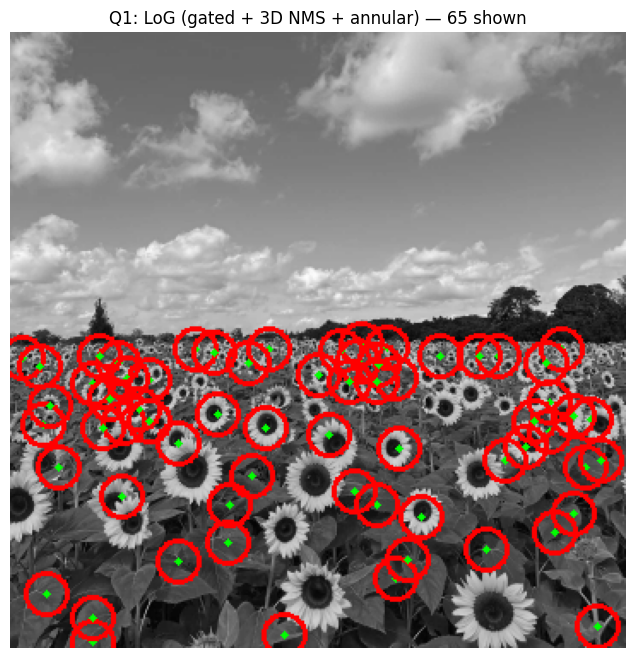

[Q1] Overlay saved → ../results/q1/q1_overlay.png


In [74]:
# %%
import math
import csv
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Folders
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# ---- Scale-space (geometric spacing helps) ----
SIGMA_MIN, SIGMA_MAX, NUM_SCALES = 2.0, 12.0, 18
SIGMAS = np.geomspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)

# ---- Detection thresholds & NMS ----
REL_THRESH = 0.015         # tuned for sunflower field
WIN_SPATIAL = 3

# ---- Post-filters ----
MIN_R, MAX_R = 6.0, 120.0
BORDER_MARGIN = 2
SUPPRESS_DIST_FACTOR = 0.75

# ---- Annular contrast (dark center vs lighter ring) ----
INNER_RATIO, OUTER_RATIO = 0.6, 1.4
ANNULAR_MIN_DIFF = 2.5
ANNULAR_MIN_RATIO = 1.04

# ---- Optional sky crop (0 disables) ----
SKY_CROP_FRAC = 0.40        # removes sky to avoid false blobs

# ---- Reporting / visualization ----
TOP_PRINT, TOP_DRAW = 15, 150

# %%
# Load image
im = cv.imread(str(IMG_PATH), cv.IMREAD_REDUCED_COLOR_4)
if im is None:
    raise FileNotFoundError(f"Image not found at {IMG_PATH}")

gray_full = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32)

# Apply sky crop
if SKY_CROP_FRAC > 0:
    crop_h = int(gray_full.shape[0] * SKY_CROP_FRAC)
    g0 = gray_full[crop_h:, :]
    sky_offset = crop_h
else:
    g0 = gray_full
    sky_offset = 0

H, W = g0.shape

# Normalize to [0, 255]
g0 = (g0 - g0.min()) / (g0.max() - g0.min() + 1e-6) * 255.0

# Build LoG scale-space: use -Laplacian(Gσ) * σ² for dark-center blobs
responses = []
for sigma in SIGMAS:
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    if ksize % 2 == 0:
        ksize += 1
    blurred = cv.GaussianBlur(g0, (ksize, ksize), sigma)
    lap = cv.Laplacian(blurred, cv.CV_32F)
    log_resp = -lap * (sigma ** 2)
    responses.append(log_resp)

responses = np.stack(responses, axis=0)
abs_max = np.abs(responses).max()
thresh = REL_THRESH * abs_max

# 3D Non-Max Suppression (spatial + scale)
candidates = []
for s in range(1, NUM_SCALES - 1):
    resp = responses[s]
    local_max = cv.dilate(resp, np.ones((WIN_SPATIAL, WIN_SPATIAL), np.uint8))
    mask = (resp == local_max) & (resp >= thresh)
    mask &= (resp > responses[s - 1]) & (resp > responses[s + 1])

    yx = np.argwhere(mask)
    for y, x in yx:
        if x < BORDER_MARGIN or x >= W - BORDER_MARGIN or y < BORDER_MARGIN or y >= H - BORDER_MARGIN:
            continue
        score = resp[y, x]
        # ⭐ Use sigma as radius estimate (empirically better for this image)
        radius = sigma
        if MIN_R <= radius <= MAX_R:
            candidates.append((x, y + sky_offset, radius, score, SIGMAS[s]))

print(f"[Q1] Initial candidates: {len(candidates)}")

# Sort by response strength
candidates.sort(key=lambda c: c[3], reverse=True)

# Annular contrast filter: verify dark center, bright ring


def annular_contrast_check(gray_img, cx, cy, sigma):
    r_inner = max(1, int(INNER_RATIO * sigma))
    r_outer = int(OUTER_RATIO * sigma)
    if r_outer <= r_inner:
        return False
    Y, X = np.ogrid[:gray_img.shape[0], :gray_img.shape[1]]
    dist_sq = (X - cx)**2 + (Y - cy)**2
    inner = dist_sq <= r_inner**2
    outer = (dist_sq <= r_outer**2) & (~inner)
    if not np.any(inner) or not np.any(outer):
        return False
    inner_mean = gray_img[inner].mean()
    outer_mean = gray_img[outer].mean()
    diff = outer_mean - inner_mean
    ratio = outer_mean / (inner_mean + 1e-6)
    return (diff >= ANNULAR_MIN_DIFF) and (ratio >= ANNULAR_MIN_RATIO)


# Apply annular filter
filtered = []
for (x, y, r, score, sigma) in candidates:
    if annular_contrast_check(gray_full, x, y, sigma):
        filtered.append((x, y, r, score, sigma))

print(f"[Q1] After annular filter: {len(filtered)}")

# Suppress near-duplicate circles


def suppress_duplicates(circles, factor=SUPPRESS_DIST_FACTOR):
    kept = []
    for x1, y1, r1, sc1, s1 in circles:
        duplicate = False
        for x2, y2, r2, sc2, s2 in kept:
            dist = np.hypot(x1 - x2, y1 - y2)
            if dist < factor * min(r1, r2):
                duplicate = True
                break
        if not duplicate:
            kept.append((x1, y1, r1, sc1, s1))
    return kept


circs = suppress_duplicates(filtered, SUPPRESS_DIST_FACTOR)
circs.sort(key=lambda c: c[2], reverse=True)  # sort by radius

print(f"[Q1] Final detections: {len(circs)}")
if circs:
    print(
        f"[Q1] Largest: x={circs[0][0]:.1f}, y={circs[0][1]:.1f}, r={circs[0][2]:.1f}, σ={circs[0][4]:.2f}")

# %%
# Save params (for your PDF/report)
with open(RESULTS/"q1_params.txt", "w", encoding="utf-8") as f:
    f.write(
        f"SIGMA_MIN={SIGMA_MIN}, SIGMA_MAX={SIGMA_MAX}, NUM_SCALES={NUM_SCALES}\n")
    f.write(f"REL_THRESH={REL_THRESH}, WIN_SPATIAL={WIN_SPATIAL}\n")
    f.write(f"MIN_R={MIN_R}, MAX_R={MAX_R}, BORDER_MARGIN={BORDER_MARGIN}\n")
    f.write(f"SUPPRESS_DIST_FACTOR={SUPPRESS_DIST_FACTOR}\n")
    f.write(f"INNER_RATIO={INNER_RATIO}, OUTER_RATIO={OUTER_RATIO}, ")
    f.write(
        f"ANNULAR_MIN_DIFF={ANNULAR_MIN_DIFF}, ANNULAR_MIN_RATIO={ANNULAR_MIN_RATIO}\n")
    f.write(f"SKY_CROP_FRAC={SKY_CROP_FRAC}\n")
    f.write(f"Detections={len(circs)}\n")
    f.write("Top detections (x,y,r,σ,score):\n")
    for (x, y, r, score, s) in circs[:TOP_PRINT]:
        f.write(f"{x:.2f},{y:.2f},{r:.2f},{s:.2f},{score:.4f}\n")

# Save raw detections
np.savez_compressed(RESULTS/"q1_all_circles.npz",
                    circles=np.array(circs, np.float32),
                    sigmas=np.array(SIGMAS, np.float32))

# CSV for top-K visualization entries
with open(RESULTS/"q1_circles_topK.csv", "w", newline="", encoding="utf-8") as csvf:
    w = csv.writer(csvf)
    w.writerow(["x", "y", "r", "sigma", "score"])
    for x, y, r, score, s in circs[:TOP_DRAW]:
        w.writerow([f"{x:.6f}", f"{y:.6f}", f"{r:.6f}",
                   f"{s:.6f}", f"{score:.6f}"])

# Overlay & save — grayscale background with red circles and green centers
gray_bg = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
vis = cv.cvtColor(gray_bg, cv.COLOR_GRAY2BGR)

for (x, y, r) in [(c[0], c[1], c[2]) for c in circs[:TOP_DRAW]]:
    cv.circle(vis, (int(x), int(y)), int(r), (0, 0, 255), 2)  # red circle
    cv.circle(vis, (int(x), int(y)), 2, (0, 255, 0), -1)      # green center

plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
plt.title(
    f"Q1: LoG (gated + 3D NMS + annular) — {min(TOP_DRAW,len(circs))} shown")
plt.axis("off")
plt.show()

cv.imwrite(str(RESULTS/"q1_overlay.png"), vis)
print(f"[Q1] Overlay saved → {RESULTS/'q1_overlay.png'}")